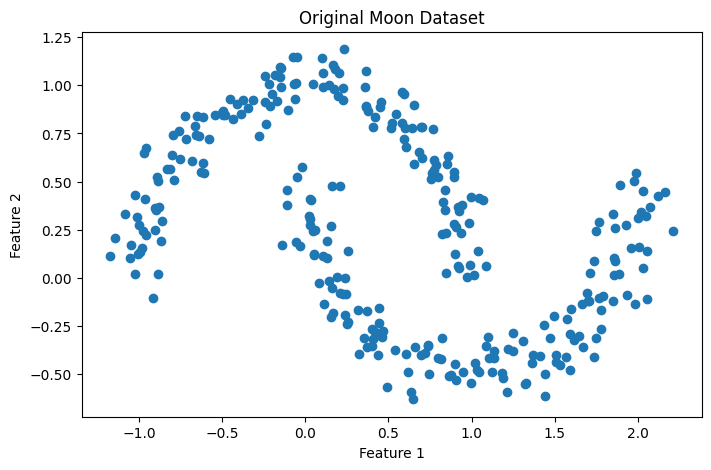

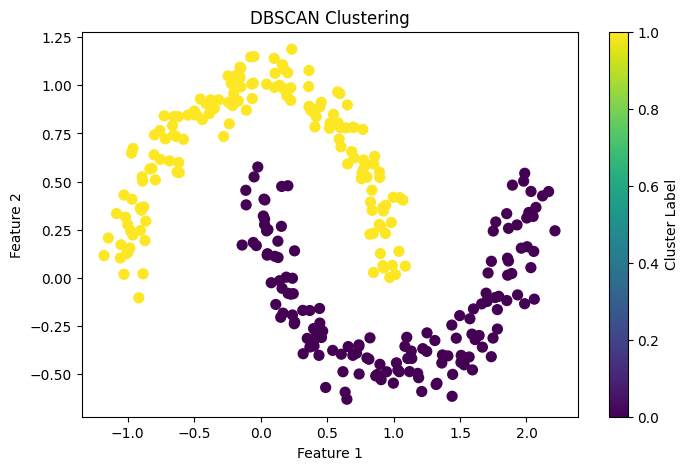

Evaluation Results
-------------------------
Number of Clusters: 2
Number of Noise Points: 0
Silhouette Score: 0.3272557786829981
Cluster 0: 150 data points
Cluster 1: 150 data points


In [1]:
# ==========================================
# Experiment 5: DBSCAN Clustering
# ==========================================

# 1. Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


# 2. Generate synthetic dataset
X, y = make_moons(
    n_samples=300,
    noise=0.08,
    random_state=42
)


# 3. Visualize original dataset
plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1])

plt.title("Original Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ==========================================
# 4. Apply DBSCAN
# ==========================================

dbscan = DBSCAN(
    eps=0.2,
    min_samples=5
)

labels = dbscan.fit_predict(X)


# ==========================================
# 5. Visualize Clusters
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster Label")
plt.show()


# ==========================================
# 6. Evaluation
# ==========================================

# Identify non-noise points
mask = labels != -1

# Count clusters excluding noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Count noise points
n_noise = np.sum(labels == -1)

print("Evaluation Results")
print("-------------------------")
print("Number of Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)

# Calculate Silhouette Score if valid
if n_clusters >= 2 and np.sum(mask) > n_clusters:

    score = silhouette_score(
        X[mask],
        labels[mask]
    )

    print("Silhouette Score:", score)

else:
    print("Silhouette Score: Not applicable")


# ==========================================
# 7. Cluster Information
# ==========================================

for i in sorted(set(labels)):
    if i == -1:
        print(f"Noise Points: {np.sum(labels == i)}")
    else:
        print(f"Cluster {i}: {np.sum(labels == i)} data points")